# Cars Dataset: Exploratory Data Analysis

This notebook profiles vehicle specifications and explores how they relate to MSRP. The modeling target is MSRP; plots are descriptive and do not imply causal relationships.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = Path('data/Cars_data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/Cars_data.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Dataset overview and quality

In [2]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.dtypes.rename('dtype').to_frame())
quality = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (100 * df.isna().mean()).round(2),
    'unique_values': df.nunique(dropna=True),
}).sort_values('missing_count', ascending=False)
display(quality)
print(f'Duplicate rows: {df.duplicated().sum():,}')
display(df.describe(include='all').T)

Shape: 11,914 rows x 16 columns


,dtype
Make,str
Model,str
Year,int64
Engine Fuel Type,str
Engine HP,float64
Engine Cylinders,float64
Transmission Type,str
Driven_Wheels,str
Number of Doors,float64
Market Category,str


,missing_count,missing_pct,unique_values
Market Category,3742,31.41,71
Engine HP,69,0.58,356
Engine Cylinders,30,0.25,9
Number of Doors,6,0.05,3
Engine Fuel Type,3,0.03,10
Model,0,0.00,915
Year,0,0.00,28
Make,0,0.00,48
Driven_Wheels,0,0.00,4
Transmission Type,0,0.00,5


Duplicate rows: 715


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,11914,48,Chevrolet,1123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,11914,915,Silverado 1500,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,11914.0,NaN,NaN,NaN,2010.384338,7.57974,1990.0,2007.0,2015.0,2016.0,2017.0
Engine Fuel Type,11911,10,regular unleaded,7172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine HP,11845.0,NaN,NaN,NaN,249.38607,109.19187,55.0,170.0,227.0,300.0,1001.0
Engine Cylinders,11884.0,NaN,NaN,NaN,5.628829,1.780559,0.0,4.0,6.0,6.0,16.0
Transmission Type,11914,5,AUTOMATIC,8266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driven_Wheels,11914,4,front wheel drive,4787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Doors,11908.0,NaN,NaN,NaN,3.436093,0.881315,2.0,2.0,4.0,4.0,4.0
Market Category,8172,71,Crossover,1110,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## MSRP distribution

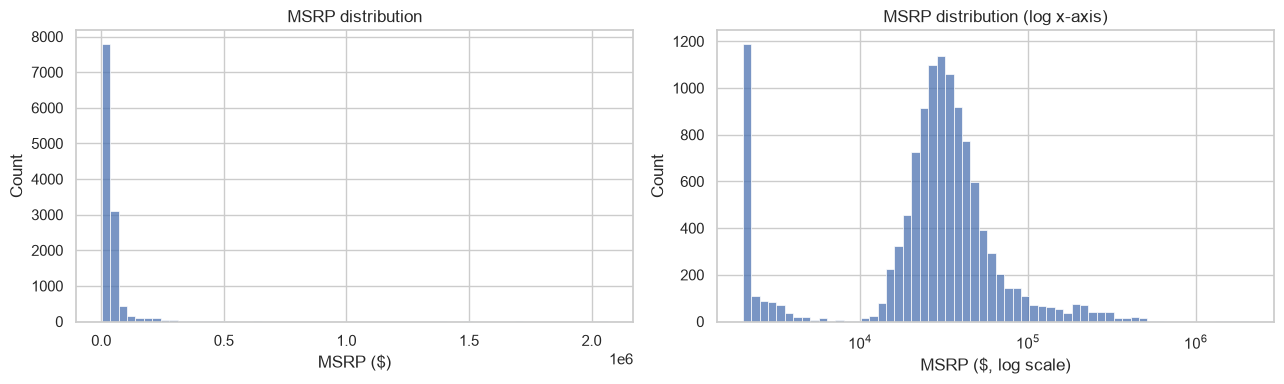

count      11914.00
mean       40594.74
std        60109.10
min         2000.00
25%        21000.00
50%        29995.00
75%        42231.25
max      2065902.00
Name: MSRP, dtype: float64
MSRP skew: 11.77


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['MSRP'], bins=60, ax=axes[0])
axes[0].set(title='MSRP distribution', xlabel='MSRP ($)')
sns.histplot(df['MSRP'], bins=60, log_scale=(True, False), ax=axes[1])
axes[1].set(title='MSRP distribution (log x-axis)', xlabel='MSRP ($, log scale)')
plt.tight_layout()
plt.show()
print(df['MSRP'].describe().round(2))
print(f'MSRP skew: {df["MSRP"].skew():.2f}')

## Price across vehicle groups

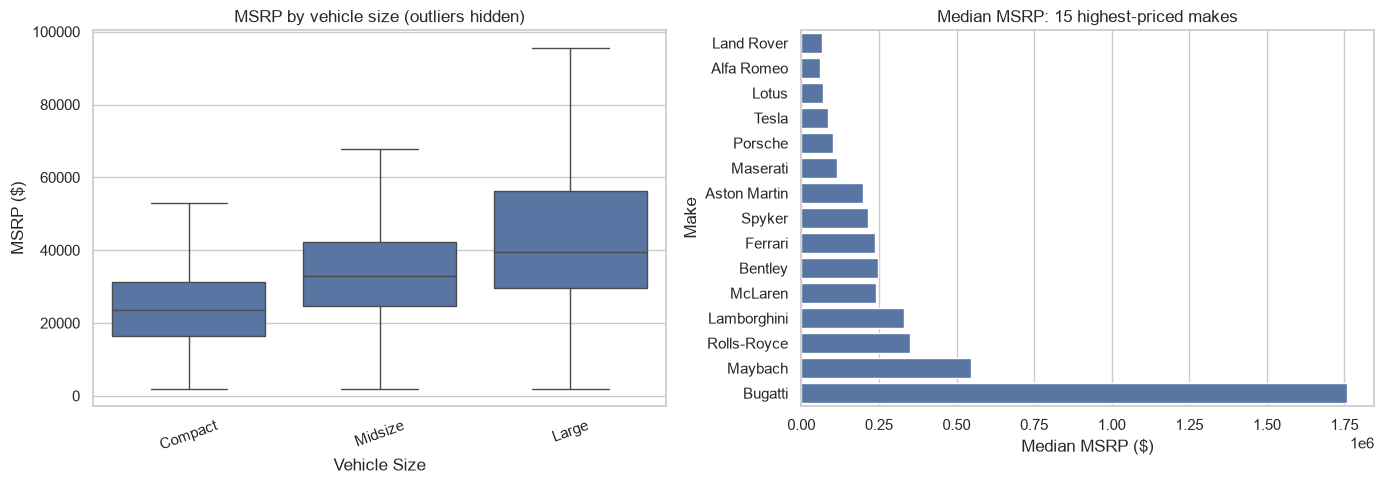

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
size_order = df.groupby('Vehicle Size')['MSRP'].median().sort_values().index
sns.boxplot(data=df, x='Vehicle Size', y='MSRP', order=size_order, showfliers=False, ax=axes[0])
axes[0].tick_params(axis='x', rotation=20)
axes[0].set(title='MSRP by vehicle size (outliers hidden)', ylabel='MSRP ($)')
top_makes = df.groupby('Make')['MSRP'].median().nlargest(15).sort_values().index
sns.barplot(data=df[df['Make'].isin(top_makes)], x='MSRP', y='Make', order=top_makes, errorbar=None, ax=axes[1])
axes[1].set(title='Median MSRP: 15 highest-priced makes', xlabel='Median MSRP ($)')
plt.tight_layout()
plt.show()

## Numeric relationships

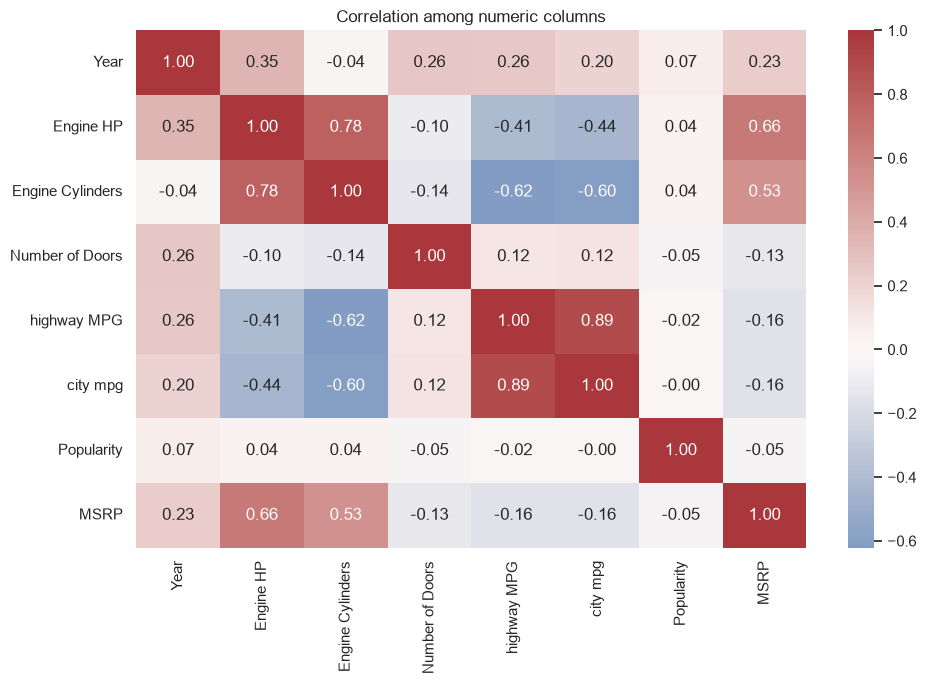

,correlation_with_MSRP
Engine HP,0.662008
Engine Cylinders,0.531312
Year,0.227590
highway MPG,-0.160043
city mpg,-0.157676
Number of Doors,-0.126635
Popularity,-0.048476


In [5]:
numeric = df.select_dtypes(include='number')
corr = numeric.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Correlation among numeric columns')
plt.tight_layout()
plt.show()
display(corr['MSRP'].drop('MSRP').sort_values(key=abs, ascending=False).to_frame('correlation_with_MSRP'))

## Modeling notes

The dataset contains a small number of missing values in several specification fields, so the training pipeline imputes missing numeric values with medians and categorical values with the most frequent value. MSRP is strongly right-skewed, so candidate regressors are trained against `log1p(MSRP)` and compared on the original dollar scale. All encoding and imputation are fit only on each training fold to avoid leakage.